In [45]:
# TensorFlow and tf.keras
import tensorflow as tf

# Helper libraries
import numpy as np
import matplotlib.pyplot as plt

print(tf.__version__)

2.11.0


In [46]:
fashion_mnist = tf.keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

In [47]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [48]:
train_images.shape

(60000, 28, 28)

In [49]:
len(train_labels)

60000

In [50]:
train_labels

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

In [51]:
test_images.shape

(10000, 28, 28)

In [52]:
len(test_labels)

10000

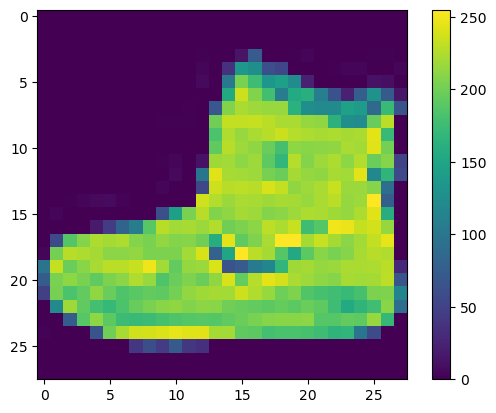

In [53]:
plt.figure()
plt.imshow(train_images[0])
plt.colorbar()
plt.grid(False)
plt.show()

In [54]:
train_images = train_images / 255.0

test_images = test_images / 255.0

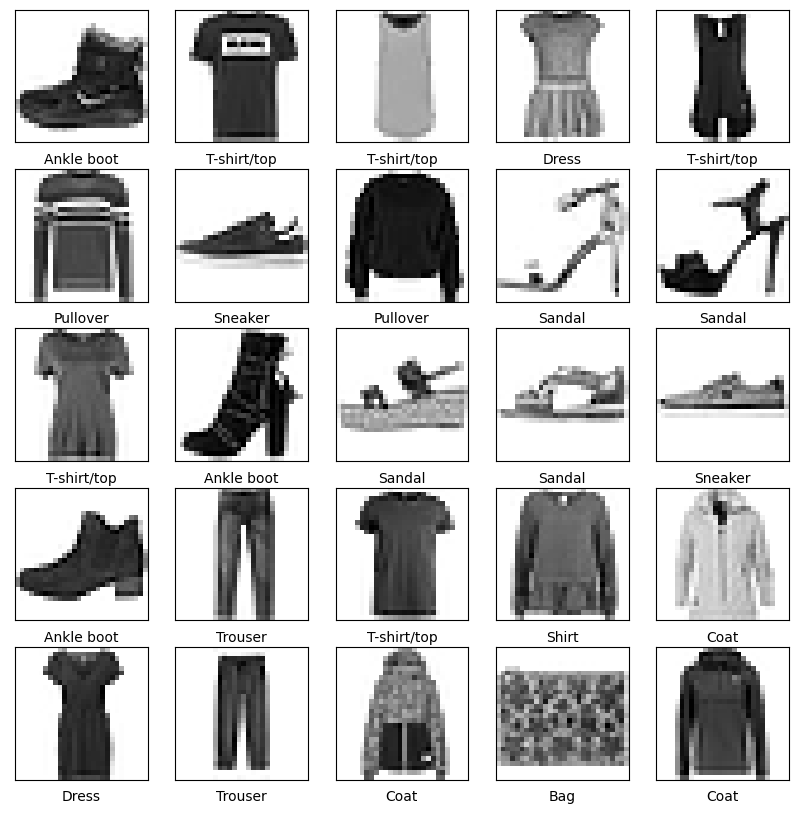

In [55]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[i]])
plt.show()

In [56]:
# Model
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(10, activation='relu'),
])

# Model Compile
model.compile(optimizer='adam',
                loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                metrics=['accuracy'])

# Model Training
model.fit(train_images, train_labels, epochs=10)

# Model Evaluation
test_loss_A, test_acc_A = model.evaluate(test_images, test_labels, verbose=2)
print('\nTest accuracy for Model:', test_acc_A)

print("The Weight")
print(model.layers[1].weights)


1875/1875 [==============================] - 2s 790us/step - loss: 1.2871 - accuracy: 0.5391
313/313 - 0s - loss: 1.1963 - accuracy: 0.5592 - 267ms/epoch - 852us/step

Test accuracy for Model: 0.5591999888420105
The Weight
[<tf.Variable 'dense_23/kernel:0' shape=(784, 10) dtype=float32, numpy=
array([[-0.0105877 ,  0.03988504, -0.04983397, ...,  0.06777098,
         0.05819315, -0.04853911],
       [ 0.07484275,  0.0575683 ,  0.05135733, ..., -0.0006158 ,
        -0.0856045 , -0.00029795],
       [ 0.12654383, -0.05429216, -0.15878078, ..., -0.02579233,
         0.02934736, -0.00621164],
       ...,
       [-0.1947432 , -0.00449497,  0.16287486, ...,  0.02240068,
        -0.06396476,  0.01405755],
       [-0.19164191, -0.02051964,  0.11052251, ..., -0.03172271,
         0.06905178,  0.01242602],
       [-0.0712984 ,  0.0639252 ,  0.1110278 , ..., -0.03531107,
         0.03334513,  0.0622681 ]], dtype=float32)>, <tf.Variable 'dense_23/bias:0' shape=(10,) dtype=float32, numpy=
array([ 0.

(10, 784)


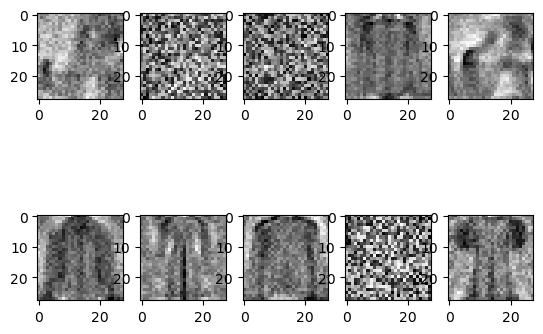

In [58]:
node_weights = model.layers[1].get_weights()[0]
node_weights = np.rot90(node_weights)

print(node_weights.shape)

fig, axs = plt.subplots(2, 5)
row = -1

for i in range(node_weights.shape[0]):
    if i % 5 == 0:
        row += 1
    axs[row, i % 5].imshow(node_weights[i].reshape(28, 28), cmap=plt.cm.binary)

plt.show()


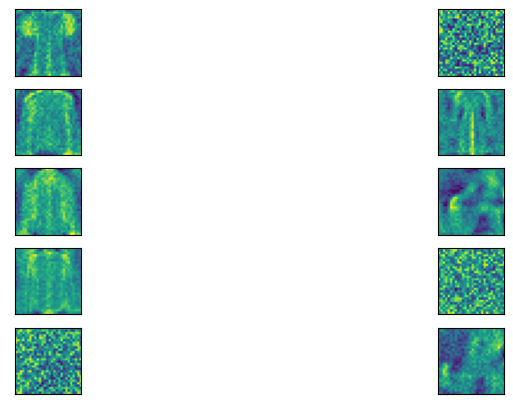

In [59]:
# Get the weights of the first layer
weights, biases = model.layers[1].get_weights()

# Plot the weights
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(5, 2, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(np.reshape(weights[:, i], (28, 28)), cmap='viridis')
plt.show()